In [12]:
import yaml

with open("config.base_s_25_elec_Ep100.yaml") as stream:
    try:
        config_original = (yaml.safe_load(stream))
    except yaml.YAMLError as exc:
        print(exc)

In [13]:
solver_options_net = config_original["solving"]["solver_options"]["gurobi-default"]
solver_options_net.update({"DualReductions": 0})
#solver_options_net = config_original["solving"]["solver_options"]["gurobi-numeric-focus"]
solver_name = config_original["solving"][("solver")]
solver_name = {'solver_name': "gurobi"}
solver_options = solver_name | solver_options_net
solver_options

{'solver_name': 'gurobi',
 'threads': 32,
 'method': 2,
 'crossover': 0,
 'BarConvTol': 1e-05,
 'Seed': 123,
 'AggFill': 0,
 'PreDual': 0,
 'GURO_PAR_BARDENSETHRESH': 200,
 'DualReductions': 0}

In [14]:
import pypsa
import fbmc  # noqa: F401  not unused; registers pypsa.Network.fbmc accessor
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx
import ahc.ahc_preproc


In [15]:
nodal_net = pypsa.Network("base_s_25_elec_Ep100.nc")
nodal_net.buses.rename(columns={"country": "zone_name"}, inplace=True)
nodal_net.set_snapshots(nodal_net.snapshots[:500])

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units


In [16]:
def freeze_expansion(network):
    """
    Replace nominal capacities by their optimized values and
    disable further expansion.

    Parameters
    ----------
    network : pypsa.Network
    """

    for comp in network.components.values():
        df = getattr(network, comp.list_name, None)

        if df is None or df.empty:
            continue

        cols = df.columns

        # p_nom -> p_nom_opt
        if "p_nom" in cols and "p_nom_opt" in cols:
            df["p_nom"] = df["p_nom_opt"]
            if "p_nom_extendable" in cols:
                df["p_nom_extendable"] = False

        # s_nom -> s_nom_opt
        if "s_nom" in cols and "s_nom_opt" in cols:
            df["s_nom"] = df["s_nom_opt"]
            if "s_nom_extendable" in cols:
                df["s_nom_extendable"] = False

        # e_nom -> e_nom_opt
        if "e_nom" in cols and "e_nom_opt" in cols:
            df["e_nom"] = df["e_nom_opt"]
            if "e_nom_extendable" in cols:
                df["e_nom_extendable"] = False

    return network

In [17]:
freeze_expansion(nodal_net)

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 25
 - Carrier: 19
 - Generator: 256
 - Line: 46
 - Link: 36
 - Load: 25
 - StorageUnit: 25
Snapshots: 500

In [18]:
nodal_net.buses.loc["DK1 0", "zone_name"] = "DK-10"
nodal_net.buses.loc["DK1 3", "zone_name"] = "DK-13"
nodal_net.buses.loc["DK3 0", "zone_name"] = "DK-30"
nodal_net.buses.loc["GB2 0", "zone_name"] = "NIR"
nodal_net.remove("Bus", "DK1 3")

In [19]:
LOAD_SHEDDING_COST = 1e4  # €/MWh or sufficiently large penalty

nodal_net.add(
    "Generator",
    nodal_net.buses.index,
    bus=nodal_net.buses.index,
    carrier="load_shedding",
    p_nom=1e9,                 # effectively unlimited
    marginal_cost=LOAD_SHEDDING_COST,
)

Index(['BE1 0', 'DE1 0', 'DE1 1', 'DE1 2', 'DE1 3', 'DE1 4', 'DE1 5', 'DE1 6',
       'DK1 0', 'DK3 0', 'FR1 0', 'FR1 1', 'FR1 2', 'FR1 3', 'FR1 4', 'FR1 5',
       'FR1 6', 'GB0 0', 'GB0 1', 'GB0 2', 'GB0 3', 'GB2 0', 'IE2 0', 'LU1 0',
       'NL1 0'],
      dtype='object', name='Bus')

In [20]:
bus_zone_map = nodal_net.buses['zone_name']

In [21]:
nodal_net, bus_zone_map = ahc.ahc_preproc.set_ahc(nodal_net, bus_zone_map)

In [22]:
nodal_net.buses_t.p.columns

Index(['BE1 0', 'DE1 0', 'DE1 1', 'DE1 2', 'DE1 3', 'DE1 4', 'DE1 5', 'DE1 6',
       'DK1 0', 'DK3 0', 'FR1 0', 'FR1 1', 'FR1 2', 'FR1 3', 'FR1 4', 'FR1 5',
       'FR1 6', 'GB0 0', 'GB0 1', 'GB0 2', 'GB0 3', 'GB2 0', 'IE2 0', 'LU1 0',
       'NL1 0', 'VH FR1 3', 'VH GB0 2', 'VH DK3 0', 'VH DK1 0', 'VH GB2 0',
       'VH GB0 1', 'VH BE1 0', 'VH IE2 0', 'VH DE1 4', 'VH GB0 0', 'VH NL1 0',
       'VH FR1 6', 'VH DE1 3', 'VH GB0 3', 'VH DE1 0', 'VH FR1 2'],
      dtype='object', name='Bus')

In [51]:
bus_zone_map = nodal_net.buses['zone_name']

In [40]:
nodal_net_opt = nodal_net.copy()
nodal_net_opt.optimize(**solver_options)

Index(['FR1 3 <-> VH FR1 3', 'GB0 2 <-> VH GB0 2', 'DK3 0 <-> VH DK3 0',
       'DK1 0 <-> VH DK1 0', 'GB2 0 <-> VH GB2 0', 'GB0 1 <-> VH GB0 1',
       'BE1 0 <-> VH BE1 0', 'IE2 0 <-> VH IE2 0', 'DE1 4 <-> VH DE1 4',
       'GB0 0 <-> VH GB0 0', 'NL1 0 <-> VH NL1 0', 'FR1 6 <-> VH FR1 6',
       'DE1 3 <-> VH DE1 3', 'GB0 3 <-> VH GB0 3', 'DE1 0 <-> VH DE1 0',
       'FR1 2 <-> VH FR1 2'],
      dtype='object', name='Line')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 32
 - method: 2
 - crossover: 0
 - BarConvTol: 1e-05
 - Seed: 123
 - AggFill: 0
 - PreDual: 0
 - GURO_PAR_BARDENSETHRESH: 200
 - DualReductions: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 440.62it/s]
INFO:linopy.io: Writing time: 0.23s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2838876


INFO:gurobipy:Set parameter LicenseID to value 2838876


...

INFO:gurobipy:Barrier solved model in 29 iterations and 0.97 seconds (1.38 work units)


Optimal objective 2.92561278e+09


INFO:gurobipy:Optimal objective 2.92561278e+09


INFO:gurobipy:
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 214500 primals, 474500 duals
Objective: 2.93e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [56]:
nodal_net_opt.buses_t.p["VH FR1 3"]

snapshot
2013-01-01 00:00:00    1000.726073
2013-01-01 01:00:00    1000.725881
2013-01-01 02:00:00    1000.725760
2013-01-01 03:00:00    1000.725818
2013-01-01 04:00:00    1000.725914
                          ...     
2013-01-21 15:00:00    1000.688204
2013-01-21 16:00:00    1000.711927
2013-01-21 17:00:00    1000.715141
2013-01-21 18:00:00    1000.714973
2013-01-21 19:00:00    1000.712084
Name: VH FR1 3, Length: 500, dtype: float64

In [68]:
nodal_net_opt.lines_t.p0["FR1 3 <-> VH FR1 3"]

snapshot
2013-01-01 00:00:00   -1000.726073
2013-01-01 01:00:00   -1000.725881
2013-01-01 02:00:00   -1000.725760
2013-01-01 03:00:00   -1000.725818
2013-01-01 04:00:00   -1000.725914
                          ...     
2013-01-21 15:00:00   -1000.688204
2013-01-21 16:00:00   -1000.711927
2013-01-21 17:00:00   -1000.715141
2013-01-21 18:00:00   -1000.714973
2013-01-21 19:00:00   -1000.712084
Name: FR1 3 <-> VH FR1 3, Length: 500, dtype: float64

In [71]:
nodal_net_opt.links_t.p1[["TYNDP2020_17", "TYNDP2024_153"] ]

Link,TYNDP2020_17,TYNDP2024_153
snapshot,,
2013-01-01 00:00:00,-0.259885,-0.455614
2013-01-01 01:00:00,-0.259887,-0.455620
2013-01-01 02:00:00,-0.259891,-0.455626
2013-01-01 03:00:00,-0.259956,-0.455626
2013-01-01 04:00:00,-0.259975,-0.455627
...,...,...
2013-01-21 15:00:00,-0.252220,-0.449527
2013-01-21 16:00:00,-0.257026,-0.453544
2013-01-21 17:00:00,-0.257574,-0.453967


In [69]:
nodal_net.links.query('bus1 == "VH FR1 3"')

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,p_nom_opt,voltage,underground,under_construction,tags,geometry,dc,underwater_fraction,project_status,reversed
Link,,,,,,,,,,,,,,,,,,,,,
TYNDP2020_17,VH IE2 0,VH FR1 3,,DC,1.0,True,2026,inf,0.260852,0.0,...,0.260852,NaN,1.0,True,"""url""=>""https://tyndp2020-project-platform.azu...","LINESTRING (-8.36471600000001 51.892597, -4.23...",NaN,0.95,in_permitting,False
TYNDP2024_153,VH GB0 0,VH FR1 3,,DC,1.0,True,2031,inf,0.456500,0.0,...,0.456500,NaN,NaN,True,"{name:France-Alderney-Britain,url:https://eepu...","LINESTRING (-3.533899 50.718412, -1.469216 49....",NaN,0.71,in_permitting,False


In [72]:
nodal_net_opt.buses_t.p["VH FR1 3"]

snapshot
2013-01-01 00:00:00    1000.726073
2013-01-01 01:00:00    1000.725881
2013-01-01 02:00:00    1000.725760
2013-01-01 03:00:00    1000.725818
2013-01-01 04:00:00    1000.725914
                          ...     
2013-01-21 15:00:00    1000.688204
2013-01-21 16:00:00    1000.711927
2013-01-21 17:00:00    1000.715141
2013-01-21 18:00:00    1000.714973
2013-01-21 19:00:00    1000.712084
Name: VH FR1 3, Length: 500, dtype: float64

In [53]:
zonal_net = nodal_net.fbmc.to_zonal(bus_zone_map)

In [19]:
len(nodal_net.buses.index)

41

In [54]:
config = fbmc.FBMCConfig(
    base_case_strategy=fbmc.BaseCaseStrategy.ZERO_FLOWS,
    add_security_constraints=False,
    gsk_strategy=fbmc.GSKStrategy.P_NOM,
    security_constraint_bodf_size_threshold=0.1,
    min_ram=0.1,
    reliability_margin_factor=0.0,
    advanced_hybrid_coupling_flag= True,
    #solver_kwargs={'solver_name': 'gurobi', 'OutputFlag': 0},
    solver_kwargs=solver_options
)

zonal_net.fbmc.create_model(nodal_net, config=config)

       'relation/15772117-320-DC', 'relation/15781671-525-DC',
       'relation/2127794-270-DC', 'relation/2505320-400-DC',
       'relation/5487095-400-DC', 'relation/6914309-500-DC',
       'relation/8184641-200-DC', 'relation/8185420-320-DC',
       'relation/8185487-400-DC', 'relation/8193755-320-DC', 'TYNDP2020_17',
       'TYNDP2020_32', 'TYNDP2020_36', 'DC2', 'TYNDP2024_153', 'TYNDP2024_285',
       'TYNDP2022_286'],
      dtype='object', name='Link')
INFO:root:Determined 4 sub-networks in the base case nodal network.
Index(['BE1 0', 'DE1 0', 'DE1 1', 'DE1 2', 'DE1 3', 'DE1 4', 'DE1 5', 'DE1 6',
       'DK1 0', 'DK3 0', 'FR1 0', 'FR1 1', 'FR1 2', 'FR1 3', 'FR1 4', 'FR1 5',
       'FR1 6', 'GB0 0', 'GB0 1', 'GB0 2', 'GB0 3', 'GB2 0', 'IE2 0', 'LU1 0',
       'NL1 0'],
      dtype='object', name='Generator')


zone names values ['BE' 'DE' 'DE' 'DE' 'DE' 'DE' 'DE' 'DE' 'DK-10' 'FR' 'FR' 'FR' 'FR' 'FR'
 'FR' 'FR' 'LU' 'NL' 'VH FR1 3' 'VH DK1 0' 'VH BE1 0' 'VH DE1 4'
 'VH NL1 0' 'VH FR1 6' 'VH DE1 3' 'VH DE1 0' 'VH FR1 2']
zone names values ['GB' 'GB' 'GB' 'GB' 'VH GB0 2' 'VH GB0 1' 'VH GB0 0' 'VH GB0 3']
zone names values ['NIR' 'IE' 'VH GB2 0' 'VH IE2 0']


INFO:root:Created optimization model without meshed split.


Fixed load has coordinate Bus


Linopy LP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * Link-p (snapshot, Link)
 * StorageUnit-p_dispatch (snapshot, StorageUnit)
 * StorageUnit-p_store (snapshot, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, StorageUnit)
 * Zone-p (snapshot, Zone)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * StorageUnit-fix-p_dispatch-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_dispatch-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_of_charge-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_of_charge-upper (snapshot, StorageUnit-fix)
 * StorageUnit-energy_balance (snapshot, StorageUnit)
 * Zone-definition (snapshot, Zone)
 * Bus-nodal_balance (Bus, sn

In [64]:
#nodal_net.determine_network_topology()
nodal_net.sub_networks.loc["1",:].obj.buses_i()

Index(['DK3 0', 'VH DK3 0'], dtype='object', name='Bus')

In [15]:
bus_zone_map

Bus
BE1 0             BE
DE1 0             DE
DE1 1             DE
DE1 2             DE
DE1 3             DE
DE1 4             DE
DE1 5             DE
DE1 6             DE
DK1 0          DK-10
DK3 0          DK-30
FR1 0             FR
FR1 1             FR
FR1 2             FR
FR1 3             FR
FR1 4             FR
FR1 5             FR
FR1 6             FR
GB0 0             GB
GB0 1             GB
GB0 2             GB
GB0 3             GB
GB2 0            NIR
IE2 0             IE
LU1 0             LU
NL1 0             NL
VH FR1 3    VH FR1 3
VH GB0 2    VH GB0 2
VH DK3 0    VH DK3 0
VH DK1 0    VH DK1 0
VH GB2 0    VH GB2 0
VH GB0 1    VH GB0 1
VH BE1 0    VH BE1 0
VH IE2 0    VH IE2 0
VH DE1 4    VH DE1 4
VH GB0 0    VH GB0 0
VH NL1 0    VH NL1 0
VH FR1 6    VH FR1 6
VH DE1 3    VH DE1 3
VH GB0 3    VH GB0 3
VH DE1 0    VH DE1 0
VH FR1 2    VH FR1 2
Name: zone_name, dtype: object

In [55]:
zonal_net.model.solve(**config.solver_kwargs)
result = zonal_net.fbmc.results()
print(result)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 32
 - method: 2
 - crossover: 0
 - BarConvTol: 1e-05
 - Seed: 123
 - AggFill: 0
 - PreDual: 0
 - GURO_PAR_BARDENSETHRESH: 200
 - DualReductions: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 393.76it/s]
INFO:linopy.io: Writing time: 0.16s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2838876


INFO:gurobipy:Set parameter LicenseID to value 2838876


...

INFO:gurobipy:Barrier solved model in 35 iterations and 0.98 seconds (1.75 work units)


Optimal objective 3.34286328e+09


INFO:gurobipy:Optimal objective 3.34286328e+09


INFO:gurobipy:
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 200500 primals, 464000 duals
Objective: 3.34e+09
Solver model: available
Solver message: 2

/Users/ng-work/.pyenv/versions/pypsa-fbmc/lib/python3.11/site-packages/linopy/common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/Users/ng-work/.pyenv/versions/pypsa-fbmc/lib/python3.11/site-packages/linopy/common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


FBMCResult
  zonal_net: Unnamed Network | snapshots=500 | components=[Bus:26, Generator:281, Load:41, Link:19, StorageUnit:25]
  base_case: Unnamed Network | snapshots=500 | components=[Bus:41, Generator:281, Load:41, Line:62, Link:36, StorageUnit:25, SubNetwork:4]
  net_positions: DataFrame(500, 26)
  dispatch_results: DispatchResult object with attrs: 
  generators_p: (500, 281) snapshots x generators, 
  storage_units_p: (500, 25) snapshots x storage units, 
  links_p0: (500, 19) snapshots x links, 
  storage_levels: (500, 25) snapshots x storage levels, 
  water_values: (500, 25) snapshots x water values
  fbmc_parameters: 3 subnet(s) [0, 2, 3]


/var/folders/cn/l4_9msnj2pb5tkz_l18sbgdh0000gn/T/ipykernel_6910/466962655.py:1: DeprecatedWarning: plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.
  zonal_net.plot()


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x166f7d990>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x166fb9850>},
 'flows': {}}

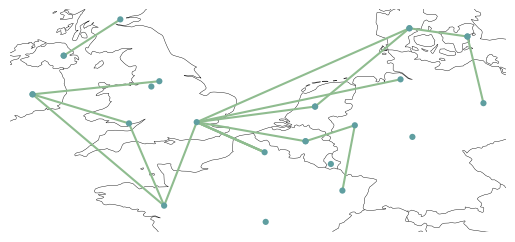

In [28]:
zonal_net.plot()

In [24]:
gm = zonal_net.model.solver_model

for c in gm.getConstrs():
    if c.IISConstr:
        row = gm.getRow(c)

        print(f"\n{c.ConstrName}")
        print(f"Sense: {c.Sense}")
        print(f"RHS: {c.RHS}")

        for i in range(row.size()):
            v = row.getVar(i)
            coeff = row.getCoeff(i)
            print(f"  {coeff} * {v.VarName}")



c156219
Sense: <
RHS: 38.00034340002179
  1.0 * x28219

c156220
Sense: <
RHS: 1120.0
  1.0 * x28220

c156221
Sense: <
RHS: 126.0
  1.0 * x28221

c156222
Sense: <
RHS: 102.0
  1.0 * x28222

c156292
Sense: <
RHS: 0.012260404990538359
  1.0 * x28292

c156314
Sense: <
RHS: -0.0
  1.0 * x28314

c156335
Sense: <
RHS: 13.894604212790181
  1.0 * x28335

c156353
Sense: <
RHS: 0.0029077523664767816
  1.0 * x28353

c156375
Sense: <
RHS: -0.0
  1.0 * x28375

c156400
Sense: <
RHS: -0.0
  1.0 * x28400

c290259
Sense: <
RHS: 366.1151138856493
  1.0 * x140259

c302759
Sense: >
RHS: -0.0
  1.0 * x152759

c397610
Sense: =
RHS: 1805.3723983764648
  1.0 * x28219
  1.0 * x28220
  1.0 * x28221
  1.0 * x28222
  1.0 * x28292
  1.0 * x28314
  1.0 * x28335
  1.0 * x28353
  1.0 * x28375
  1.0 * x28400
  1.0 * x140259
  -1.0 * x152759


In [26]:
gm.computeIIS()
gm.write("iis.ilp")
with open("iis.ilp") as f:
    print(f.read())

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 25.5.0 25F80)


INFO:gurobipy:Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 25.5.0 25F80)


INFO:gurobipy:


CPU model: Apple M4


INFO:gurobipy:CPU model: Apple M4


...

IIS computed: 13 constraints and 0 bounds


INFO:gurobipy:IIS computed: 13 constraints and 0 bounds


IIS runtime: 0.01 seconds (0.00 work units)


INFO:gurobipy:IIS runtime: 0.01 seconds (0.00 work units)


\ Model obj_copy
\ LP format - for model browsing. Use MPS format to capture full model detail.
\ Signature: 0x7851bdb56e3cfe62
Minimize
 
Subject To
 c156219: x28219 <= 38.00034340002179
 c156220: x28220 <= 1120
 c156221: x28221 <= 126
 c156222: x28222 <= 102
 c156292: x28292 <= 0.0122604049905384
 c156314: x28314 <= 0
 c156335: x28335 <= 13.89460421279018
 c156353: x28353 <= 0.00290775236647678
 c156375: x28375 <= 0
 c156400: x28400 <= 0
 c290259: x140259 <= 366.1151138856493
 c302759: x152759 >= 0
 c397610: x28219 + x28220 + x28221 + x28222 + x28292 + x28314 + x28335
   + x28353 + x28375 + x28400 + x140259 - x152759 = 1805.372398376465
Bounds
 x28219 free
 x28220 free
 x28221 free
 x28222 free
 x28292 free
 x28314 free
 x28335 free
 x28353 free
 x28375 free
 x28400 free
 x140259 free
 x152759 free
End



In [35]:
print(zonal_net.model.constraints.get_label_position(156219))

('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 CCGT'})


In [27]:


for v in gm.getVars():
    if v.VarName in [
        "x28219","x28220","x28221","x28222",
        "x28292","x28314","x28335","x28353",
        "x28375","x28400","x140259","x152759"
    ]:
        print(v.VarName)
        print("LB =", v.LB)
        print("UB =", v.UB)


x28219
LB = -inf
UB = inf
x28220
LB = -inf
UB = inf
x28221
LB = -inf
UB = inf
x28222
LB = -inf
UB = inf
x28292
LB = -inf
UB = inf
x28314
LB = -inf
UB = inf
x28335
LB = -inf
UB = inf
x28353
LB = -inf
UB = inf
x28375
LB = -inf
UB = inf
x28400
LB = -inf
UB = inf
x140259
LB = -inf
UB = inf
x152759
LB = -inf
UB = inf


In [44]:
int("23")

23

In [45]:
gm = zonal_net.model.solver_model

for c in gm.getConstrs():
    if c.IISConstr:
        print(c.ConstrName[1:])
        print(zonal_net.model.constraints.get_label_position(int(c.ConstrName[1:])))



156219
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 CCGT'})
156220
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 biomass'})
156221
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 oil'})
156222
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 waste'})
156292
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 0 offwind-dc'})
156314
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 0 solar'})
156335
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 0 offwind-ac'})
156353
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:00:00'), 'Generator-fix': 'DK3 0 0 offwind-float'})
156375
('Generator-fix-p-upper', {'snapshot': Timestamp('2013-01-05 14:

In [12]:
from fbmc.post_processing.main import process_results

In [13]:
process_results(result, rd_cost= None, rd_dispatch= None, save_path = "/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt", config = config)

INFO:pypsa.network.io:Exported network 'Unnamed Network'saved to '/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/fbmc_network.nc contains: links, storage_units, generators, buses, loads, carriers


{'zonal_market_prices': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/zonal_market_prices.csv'),
 'load_shedding_zone_p': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/load_shedding_zone_p.csv'),
 'generation_mix': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/generation_mix.csv'),
 'storage_mix': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/storage_mix.csv'),
 'storage_units_p': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/storage_units_p.csv'),
 'summary': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/summary.json'),
 'linopy_model': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/linopy_model.nc'),
 'net_positions_zone_p': PosixPath('/Users/ng-work/Models/pypsa-fbmc/nathan_tests/25-nodes-ep100/results_alt/net_positions_zo

In [14]:
result.zonal_net.model.constraints["Bus-nodal_balance"].dual.to_pandas()

KeyError: 'Bus-nodal_balance'

In [34]:
result.zonal_net.model.constraints["Zone-definition"].loc[:,"IE"].dual.to_pandas()

snapshot
2013-01-01 00:00:00    0.0
2013-01-01 01:00:00    0.0
2013-01-01 02:00:00    0.0
2013-01-01 03:00:00    0.0
2013-01-01 04:00:00    0.0
                      ... 
2013-12-30 19:00:00    0.0
2013-12-30 20:00:00    0.0
2013-12-30 21:00:00    0.0
2013-12-30 22:00:00    0.0
2013-12-30 23:00:00    0.0
Length: 8736, dtype: float64

In [21]:
result.zonal_net.statistics.expanded_capacity()

component    carrier                 
Generator    Combined-Cycle Gas          0.0
             Offshore Wind (AC)          0.0
             Offshore Wind (DC)          0.0
             Offshore Wind (Floating)    0.0
             Onshore Wind                0.0
             Open-Cycle Gas              0.0
             Solar                       0.0
             biomass                     0.0
             coal                        0.0
             geothermal                  0.0
             lignite                     0.0
             nuclear                     0.0
             oil                         0.0
             solar-hsat                  0.0
             waste                       0.0
Link         DC                          0.0
StorageUnit  Battery Storage             0.0
dtype: float64

In [128]:
result.zonal_net.model.constraints["Generator-ext-p-upper"]

Constraint `Generator-ext-p-upper` [snapshot: 8736, Generator-ext: 172]:
------------------------------------------------------------------------
[2013-01-01 00:00:00, BE1 0 CCGT]: +1 Generator-p[2013-01-01 00:00:00, BE1 0 CCGT] - 1 Generator-p_nom[BE1 0 CCGT]                  ≤ -0.0
[2013-01-01 00:00:00, BE1 0 nuclear]: +1 Generator-p[2013-01-01 00:00:00, BE1 0 nuclear] - 0.781 Generator-p_nom[BE1 0 nuclear]     ≤ -0.0
[2013-01-01 00:00:00, DE1 0 CCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 0 CCGT] - 1 Generator-p_nom[DE1 0 CCGT]                  ≤ -0.0
[2013-01-01 00:00:00, DE1 0 OCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 0 OCGT] - 1 Generator-p_nom[DE1 0 OCGT]                  ≤ -0.0
[2013-01-01 00:00:00, DE1 1 CCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 1 CCGT] - 1 Generator-p_nom[DE1 1 CCGT]                  ≤ -0.0
[2013-01-01 00:00:00, DE1 1 OCGT]: +1 Generator-p[2013-01-01 00:00:00, DE1 1 OCGT] - 1 Generator-p_nom[DE1 1 OCGT]                  ≤ -0.0
[2013-01-01 00:00:00

In [117]:
nodal_net.statistics.expanded_capacity()

component    carrier                 
Generator    Combined-Cycle Gas               0.89296
             Offshore Wind (AC)               1.34084
             Offshore Wind (DC)               4.58522
             Offshore Wind (Floating)         3.49939
             Onshore Wind                 38837.28688
             Open-Cycle Gas                   0.10507
             Solar                        19085.71321
             biomass                          0.00000
             coal                             0.00000
             geothermal                       0.00000
             lignite                          0.00000
             nuclear                          0.42779
             oil                              0.00000
             solar-hsat                  135482.99670
             waste                            0.00000
Line         AC                           85080.20262
Link         DC                              14.58120
StorageUnit  Battery Storage              26

In [118]:
result.zonal_net.statistics.expanded_capacity()

component    carrier                 
Generator    Combined-Cycle Gas               0.89296
             Offshore Wind (AC)               1.34084
             Offshore Wind (DC)               4.58522
             Offshore Wind (Floating)         3.49939
             Onshore Wind                 38837.28688
             Open-Cycle Gas                   0.10507
             Solar                        19085.71321
             biomass                          0.00000
             coal                             0.00000
             geothermal                       0.00000
             lignite                          0.00000
             nuclear                          0.42779
             oil                              0.00000
             solar-hsat                  135482.99670
             waste                            0.00000
Link         DC                               3.68863
StorageUnit  Battery Storage              26355.85776
dtype: float64